In [48]:
import pandas as pd
data = pd.read_csv('StudentsPerformance.csv')

In [49]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [50]:
data.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [51]:
X = data[['reading score', 'writing score']]
y = data['math score']

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [55]:
y_pred = model.predict(X_test)

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 7.35130878253051
MSE: 77.24297821278955
R2 Score: 0.6825697127424626


In [69]:
print("Actual Values:", y_test.values[:5])
print("Predicted Values:", y_pred[:5])

Actual Values: [91 53 80 74 84]
Predicted Values: [60.82197779 74.35573506 78.57449531 41.96402352 63.81726557]


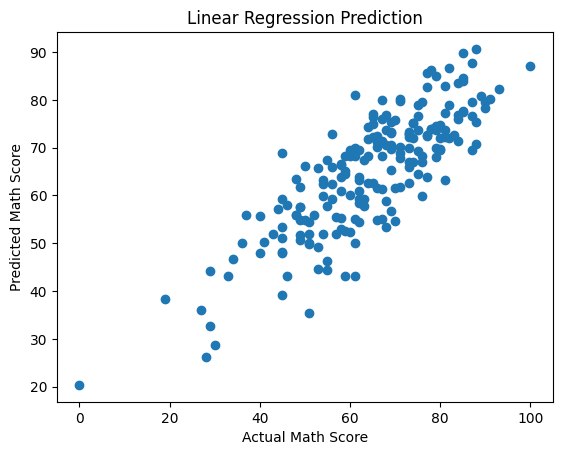

In [58]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Linear Regression Prediction")

plt.show()

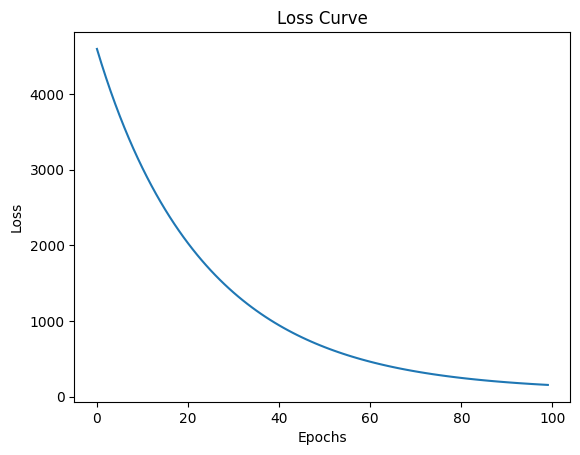

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy
X = np.array(data[['reading score', 'writing score']])
y = np.array(data['math score'])

# Normalize
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Initialize parameters
m = 0
b = 0

learning_rate = 0.01
epochs = 100

n = len(y)

losses = []

# Gradient Descent
for i in range(epochs):

    y_pred = m * X[:,0] + m * X[:,1] + b

    loss = np.mean((y - y_pred) ** 2)
    losses.append(loss)

    dm = (-2/n) * np.sum((y - y_pred) * (X[:,0] + X[:,1]))
    db = (-2/n) * np.sum(y - y_pred)

    m = m - learning_rate * dm
    b = b - learning_rate * db
plt.plot(range(epochs), losses)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.show()